In [ ]:
from totalsegmentator.python_api import totalsegmentator
import SimpleITK as sitk, nibabel as nib
import numpy as np, os

# ── 1. paths & label list ──────────────────────────────────────────────────────
dicom_dir = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000003"          # input DICOM folder
out_dir   = os.path.join(dicom_dir, "_seg_pelvis")             # output for masks
labels    = ["hip_left", "hip_right"]                          # pelvic bones
combo_f   = os.path.join(out_dir, "hips_combined.nii.gz")      # new merged file

# ── 2. run TotalSegmentator (hip bones only, fast mode) ────────────────────────
totalsegmentator(
    dicom_dir, out_dir,
    roi_subset=labels,
    fast=True,                       # flip to False for full‑resolution later
    nr_thr_resamp=1, nr_thr_saving=1,# avoid Windows multiprocessing quirks
    device="gpu"                     # "gpu" or "cpu"
)

# ── 3. load the two masks and merge them ---------------------------------------
mask_combined = None
for lab in labels:
    fpath = os.path.join(out_dir, f"{lab}.nii.gz")
    img   = nib.load(fpath)
    data  = img.get_fdata().astype(bool)

    if mask_combined is None:
        mask_combined = data
        affine, header = img.affine, img.header
    else:
        mask_combined |= data          # logical OR → one binary mask

# OPTIONAL: encode side information (1 = left, 2 = right)
# Uncomment the block below if you prefer a 2‑value label map
# mask_combined = np.zeros_like(data, dtype=np.uint8)
# mask_combined[nib.load(os.path.join(out_dir,"hip_left.nii.gz")).get_fdata().astype(bool)]  = 1
# mask_combined[nib.load(os.path.join(out_dir,"hip_right.nii.gz")).get_fdata().astype(bool)] = 2

# ── 4. save the merged mask ----------------------------------------------------
nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), combo_f)
print("✅ combined NIfTI saved ➜", combo_f)


If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (512, 512, 984)
Resampling...
  Resampled in 7.01s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 161.52it/s]


  Predicted in 6.93s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 984)
  cropping from (512, 512, 984) to (404, 240, 544)
Resampling...
  Resampled in 1.13s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 95.15it/s]


  Predicted in 6.39s
Resampling...
Saving segmentations...
  Saved in 3.02s
✅ combined NIfTI saved ➜ D:\Abdomen_CT_Bone_Mets\BMAB1_00000002\_seg_pelvis\hips_combined.nii.gz


In [5]:
import nibabel as nib
import SimpleITK as sitk
import numpy as np
import os

# ── paths ──────────────────────────────────────────────────────────────
dicom_dir = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000003"
combo_f   = os.path.join(dicom_dir, "_seg_pelvis", "hips_combined.nii.gz")

# ── load combined hip mask (shape = z, y, x) ───────────────────────────
mask_np = nib.load(combo_f).get_fdata().astype(bool)

# ── get slice spacing from the original CT series ──────────────────────
reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
z_spacing = reader.Execute().GetSpacing()[-1]      # mm per axial slice

# ── locate pubic symphysis: first slice where mask touches midline ─────
z_dim, y_dim, x_dim = mask_np.shape
mid_x = x_dim // 2
pubic_idx = None
for z in range(z_dim):                             # inferior → superior
    if mask_np[z, :, max(0, mid_x-2):mid_x+3].any():
        pubic_idx = z
        break
if pubic_idx is None:
    raise RuntimeError("Pubic symphysis not detected – widen midline band.")

pubic_mm     = pubic_idx * z_spacing               # distance from caudal edge
allowance_mm = 30.0                                # 3 cm allowance
overscan_mm  = max(0.0, pubic_mm - allowance_mm)

# ── report ─────────────────────────────────────────────────────────────
print(f"Pubic symphysis slice : {pubic_idx}")
print(f"Distance from bottom  : {pubic_mm:.1f} mm")
if overscan_mm == 0:
    print("✅ No caudal overscan (within 3 cm allowance).")
else:
    print(f"⚠️ Caudal overscan     : {overscan_mm:.1f} mm "
          f"(≈ {overscan_mm / z_spacing:.1f} slices)")

Pubic symphysis slice : 155
Distance from bottom  : 77.5 mm
⚠️ Caudal overscan     : 47.5 mm (≈ 95.0 slices)


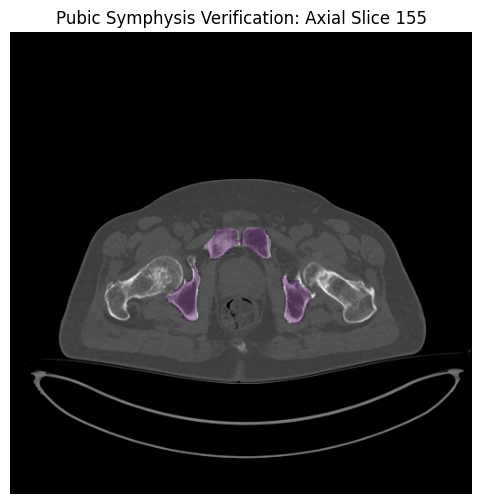

In [2]:
import SimpleITK as sitk
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os

# ── 1. Paths ──────────────────────────────────────────────────────────────────
dicom_dir = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000003"
combo_f   = os.path.join(dicom_dir, "_seg_pelvis", "hips_combined.nii.gz")

# 🔁 This line assumes pubic_idx was defined earlier in the notebook
# (via a nibabel-based detection block)
# Do NOT redefine or recalculate it here!

# ── 2. Load the CT and re-orient to RAS ───────────────────────────────────────
reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
ct_raw = reader.Execute()  # LPS orientation

orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
ct_ras = orienter.Execute(ct_raw)
ct_np = sitk.GetArrayFromImage(ct_ras)

# ── 3. Load and resample the pelvis mask to CT geometry ───────────────────────
mask_itk = sitk.ReadImage(combo_f)
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_ras)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_on_ct_itk = resampler.Execute(mask_itk)
mask_np = sitk.GetArrayFromImage(mask_on_ct_itk).astype(bool)

# ── 4. HU windowing and overlay plot ──────────────────────────────────────────
def hu_window(arr, level=400, width=2000):
    lo, hi = level - width/2, level + width/2
    arr = np.clip(arr, lo, hi)
    return ((arr - lo) / (hi - lo) * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(hu_window(ct_np[pubic_idx]), cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_np[pubic_idx], mask_np[pubic_idx]),
           alpha=0.4, origin="lower")
plt.title(f"Pubic Symphysis Verification: Axial Slice {pubic_idx}")
plt.axis("off")
plt.show()